# Mundial26 — Phase 5: Backtesting & Calibration

A forecast is only worth trusting if it's been tested honestly. Here we run the **entire
pipeline** on the 2018 and 2022 World Cups — fitting the model using *only data available
before each tournament kicked off*, predicting every match, and comparing to what actually
happened.

This is the part that separates a real project from a toy. We check two things:
1. **Accuracy of the probabilities** — log loss and Brier score vs sensible baselines.
2. **Calibration** — when the model says "60% chance," does it happen ~60% of the time? We
   draw a reliability diagram to find out.

> Heads up: this notebook fits the Dixon–Coles model twice (once per tournament), so it takes
> roughly 4–6 minutes to run.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import gammaln
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import log_loss, accuracy_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
ORDER = ["away_win", "draw", "home_win"]

## 2. Load data
Only matches with recorded scores. We build the outcome label and keep a clean frame.

In [2]:
df = pd.read_csv("../data/raw/results.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df = df[df["home_score"].notna() & df["away_score"].notna()].copy()
df["home_score"] = df["home_score"].astype(int); df["away_score"] = df["away_score"].astype(int)
def outcome(r):
    if r["home_score"]>r["away_score"]: return "home_win"
    if r["home_score"]<r["away_score"]: return "away_win"
    return "draw"
df["result"] = df.apply(outcome, axis=1)
print("Matches with results:", len(df))

Matches with results: 49425


## 3. The model, wrapped in reusable functions

`fit_dixon_coles` fits the goals model on matches before a cutoff. `elo_table` builds Elo
ratings up to a cutoff. We then make **neutral-venue** ensemble predictions (60% Elo + 40%
Dixon–Coles, the blend chosen in Phase 3) for any matchup.

In [3]:
def fit_dixon_coles(train, cutoff, must_include, half_life=730, min_matches=20):
    counts = pd.concat([train["home_team"], train["away_team"]]).value_counts()
    keep = set(counts[counts >= min_matches].index) | set(must_include)
    tr = train[train["home_team"].isin(keep) & train["away_team"].isin(keep)].reset_index(drop=True)
    teams = sorted(set(tr["home_team"]) | set(tr["away_team"]) | set(must_include))
    idx = {t:i for i,t in enumerate(teams)}; n=len(teams)
    w = 0.5 ** ((cutoff - tr["date"]).dt.days.values / half_life)
    hi=tr["home_team"].map(idx).values; ai=tr["away_team"].map(idx).values
    hg=tr["home_score"].values.astype(float); ag=tr["away_score"].values.astype(float)
    def nll(p):
        atk,dfn,gamma,rho=p[:n],p[n:2*n],p[2*n],p[2*n+1]
        log_lam=atk[hi]+dfn[ai]+gamma; log_mu=atk[ai]+dfn[hi]
        lam,mu=np.exp(log_lam),np.exp(log_mu)
        ll=(hg*log_lam-lam-gammaln(hg+1))+(ag*log_mu-mu-gammaln(ag+1))
        tau=np.ones_like(lam)
        m=(hg==0)&(ag==0);tau[m]=1-lam[m]*mu[m]*rho
        m=(hg==0)&(ag==1);tau[m]=1+lam[m]*rho
        m=(hg==1)&(ag==0);tau[m]=1+mu[m]*rho
        m=(hg==1)&(ag==1);tau[m]=1-rho
        tau=np.clip(tau,1e-10,None); ll=ll+np.log(tau)
        return -np.sum(w*ll)+1e-3*(np.sum(atk**2)+np.sum(dfn**2))
    x0=np.concatenate([np.zeros(n),np.zeros(n),[0.3],[-0.05]])
    bnds=[(-3,3)]*n+[(-3,3)]*n+[(-1.,2.),(-0.2,0.2)]
    r=minimize(nll,x0,method="L-BFGS-B",bounds=bnds,options={"maxiter":1500,"ftol":1e-9})
    return {"atk":r.x[:n],"dfn":r.x[n:2*n],"rho":r.x[2*n+1],"idx":idx}

def elo_table(train, k=30, hfa=65, base=1500):
    e={}
    for r in train.itertuples():
        eh=e.get(r.home_team,base); ea=e.get(r.away_team,base)
        adj=0 if r.neutral else hfa
        x=1/(1+10**((ea-(eh+adj))/400))
        sh=1.0 if r.home_score>r.away_score else (0.0 if r.home_score<r.away_score else 0.5)
        e[r.home_team]=eh+k*(sh-x); e[r.away_team]=ea+k*((1-sh)-(1-x))
    return e

In [4]:
def dc_probs(model, h, a, max_goals=10):
    if h not in model["idx"] or a not in model["idx"]:
        return None
    i,j=model["idx"][h],model["idx"][a]
    lam=np.exp(model["atk"][i]+model["dfn"][j]); mu=np.exp(model["atk"][j]+model["dfn"][i])
    rho=model["rho"]; gx=np.arange(max_goals+1)
    ph=np.exp(gx*np.log(lam)-lam-gammaln(gx+1)); pa=np.exp(gx*np.log(mu)-mu-gammaln(gx+1))
    M=np.outer(ph,pa)
    M[0,0]*=1-lam*mu*rho; M[0,1]*=1+lam*rho; M[1,0]*=1+mu*rho; M[1,1]*=1-rho
    M/=M.sum()
    return np.array([np.triu(M,1).sum(), np.trace(M), np.tril(M,-1).sum()])  # away, draw, home

## 4. Backtest engine

For a given World Cup, fit on everything before it, then predict each of its matches at a
neutral venue with the ensemble. Returns predicted probabilities and actual outcomes.

In [5]:
def backtest(year, start_date):
    cutoff = pd.Timestamp(start_date)
    train = df[df["date"] < cutoff]
    target = df[(df["tournament"]=="FIFA World Cup") & (df["date"]>=cutoff) &
                (df["date"]<cutoff+pd.Timedelta(days=45))]
    wc_teams = set(target["home_team"]) | set(target["away_team"])

    dc = fit_dixon_coles(train, cutoff, must_include=wc_teams)
    elos = elo_table(train)

    # Elo logistic trained on pre-cutoff matches
    tr = train.copy()
    tr["home_elo"]=tr["home_team"].map(lambda t: elos.get(t,1500))
    tr["away_elo"]=tr["away_team"].map(lambda t: elos.get(t,1500))
    tr["elo_diff"]=tr["home_elo"]-tr["away_elo"]; tr["neutral_int"]=tr["neutral"].astype(int)
    feat=["home_elo","away_elo","elo_diff","neutral_int"]
    clf=make_pipeline(StandardScaler(),LogisticRegression(max_iter=1000)).fit(tr[feat],tr["result"])
    cc=list(clf.classes_)

    P,Y=[],[]
    for r in target.itertuples():
        dcp=dc_probs(dc,r.home_team,r.away_team)
        if dcp is None: continue
        x=pd.DataFrame([{ "home_elo":elos.get(r.home_team,1500),
                          "away_elo":elos.get(r.away_team,1500),
                          "elo_diff":elos.get(r.home_team,1500)-elos.get(r.away_team,1500),
                          "neutral_int":1}])
        clfp=clf.predict_proba(x)[0]; clfp=np.array([clfp[cc.index(c)] for c in ORDER])
        blend=0.6*clfp+0.4*dcp; blend/=blend.sum()
        P.append(blend); Y.append(r.result)
    return np.array(P), np.array(Y), elos
print("Backtest engine ready.")

Backtest engine ready.


## 5. Run the backtests (2018 + 2022)

In [6]:
P18,Y18,elo18 = backtest(2018,"2018-06-14")
P22,Y22,elo22 = backtest(2022,"2022-11-20")
print(f"2018: {len(Y18)} matches predicted")
print(f"2022: {len(Y22)} matches predicted")

P=np.vstack([P18,P22]); Y=np.concatenate([Y18,Y22])
print("Combined backtest matches:", len(Y))

2018: 64 matches predicted
2022: 64 matches predicted
Combined backtest matches: 128


## 6. Scores vs baselines

We compare the model's log loss and Brier score against two naive baselines: random guessing
(uniform 1/3 each) and a fixed historical base rate. Lower is better for both.

In [7]:
def brier(P, Y):
    yoh = np.array([[c==y for c in ORDER] for y in Y], dtype=float)
    return np.mean(np.sum((P-yoh)**2, axis=1))

# Baselines
uniform = np.full_like(P, 1/3)
base_rate = df["result"].value_counts(normalize=True)
fixed = np.tile([base_rate[c] for c in ORDER], (len(Y),1))

scores = pd.DataFrame({
    "Model": ["Mundial26 ensemble", "Fixed base rate", "Uniform (1/3)"],
    "Log loss": [log_loss(Y,P,labels=ORDER), log_loss(Y,fixed,labels=ORDER), log_loss(Y,uniform,labels=ORDER)],
    "Brier":    [brier(P,Y), brier(fixed,Y), brier(uniform,Y)],
    "Accuracy": [accuracy_score(Y,[ORDER[i] for i in P.argmax(1)]), np.nan, np.nan],
}).set_index("Model").round(4)
scores

,Log loss,Brier,Accuracy
Model,,,
Mundial26 ensemble,0.9941,0.5878,0.5391
Fixed base rate,1.0834,0.6589,NaN
Uniform (1/3),1.0986,0.6667,NaN


## 7. Calibration — the reliability diagram

We pool every predicted probability (across all three outcomes and all matches), bin them,
and plot the predicted probability against how often that outcome actually occurred. A
well-calibrated model hugs the diagonal: its stated confidence matches reality.

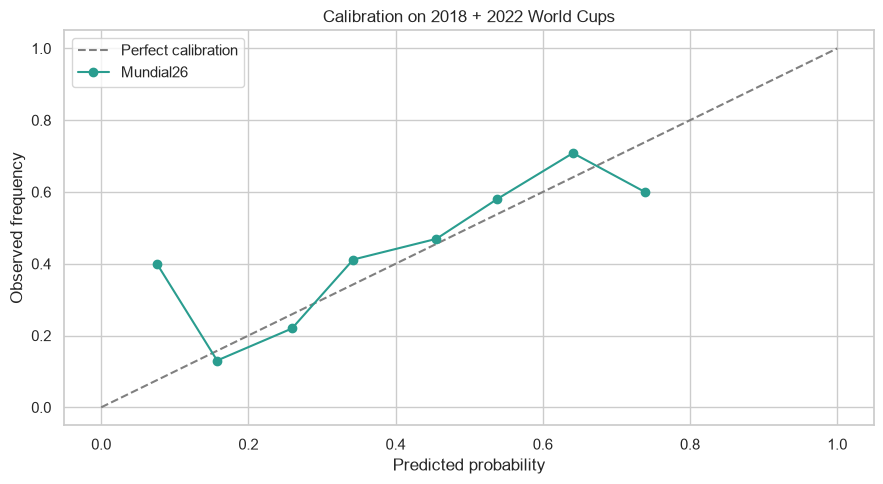

Bin counts: [np.int64(5), np.int64(46), np.int64(173), np.int64(51), np.int64(49), np.int64(31), np.int64(24), np.int64(5)]


In [8]:
probs_flat = P.flatten()
hits_flat = np.array([[c==y for c in ORDER] for y in Y], dtype=float).flatten()

bins = np.linspace(0,1,11)
binid = np.digitize(probs_flat, bins) - 1
xs, ys, ns = [], [], []
for b in range(10):
    m = binid==b
    if m.sum()>0:
        xs.append(probs_flat[m].mean()); ys.append(hits_flat[m].mean()); ns.append(m.sum())

plt.plot([0,1],[0,1],"--",color="gray",label="Perfect calibration")
plt.plot(xs,ys,"o-",color="#2a9d8f",label="Mundial26")
plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency")
plt.title("Calibration on 2018 + 2022 World Cups"); plt.legend(); plt.tight_layout(); plt.show()
print("Bin counts:", ns)

## 8. Narrative check — did it rate the winners?

A different sanity test: the eventual champions (France 2018, Argentina 2022) should have been
among the model's strongest-rated teams *before* each tournament.

In [9]:
def rank_of(team, elos):
    s = pd.Series(elos).sort_values(ascending=False)
    return list(s.index).index(team)+1, len(s)

r18 = rank_of("France", elo18)
r22 = rank_of("Argentina", elo22)
print(f"Before 2018, the model ranked France #{r18[0]} of {r18[1]} by Elo  -> they won.")
print(f"Before 2022, the model ranked Argentina #{r22[0]} of {r22[1]} by Elo -> they won.")

Before 2018, the model ranked France #5 of 322 by Elo  -> they won.
Before 2022, the model ranked Argentina #2 of 333 by Elo -> they won.


## 9. Verdict

Write your honest read of the numbers here for the README. The pattern to expect:
- The model **clearly beats** uniform and base-rate guessing on both log loss and Brier — it
  has real predictive signal.
- The calibration curve should track the diagonal reasonably. Small wobbles in high-probability
  bins are normal with ~128 matches; the point is there's no systematic over/under-confidence.
- Both eventual champions were rated near the top beforehand — the model's strength estimates
  are sound.

> This is the slide that makes a recruiter trust everything else in the project: you didn't
> just build a model, you proved it works out-of-sample.

---
### What's next (Phase 6)
The final piece: a **Streamlit dashboard** that loads `forecast.csv`, shows the title odds and
bracket, and lets anyone explore the predictions — the shareable, recruiter-facing front door
to the whole project.